Stage 1: Setup and Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print('All libraries loaded.')

All libraries loaded.


In [24]:
# Stage 1b: Upload and load the dataset files
# Uploading from local machine
from google.colab import files
print('Upload train.csv, val.csv, and test.csv when prompted.')
uploaded = files.upload()

Upload train.csv, val.csv, and test.csv when prompted.


Saving test.csv to test (1).csv
Saving val.csv to val (1).csv
Saving train.csv to train (1).csv


In [25]:
# Stage 1c: Load into DataFrames
train_df = pd.read_csv('train.csv')
val_df   = pd.read_csv('val.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train : {len(train_df)} sentences')
print(f'Val   : {len(val_df)} sentences')
print(f'Test  : {len(test_df)} sentences')
print(f'Total : {len(train_df) + len(val_df) + len(test_df)}')
print()
print('Train label balance:')
print(train_df['label_text'].value_counts())
print()
print('Test label balance:')
print(test_df['label_text'].value_counts())

Train : 2255 sentences
Val   : 576 sentences
Test  : 597 sentences
Total : 3428

Train label balance:
label_text
COMPLIANT        1142
NON_COMPLIANT    1113
Name: count, dtype: int64

Test label balance:
label_text
NON_COMPLIANT    311
COMPLIANT        286
Name: count, dtype: int64


In [26]:
# Stage 1d: Diagnose and fix missing sentence text
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    n_missing = df['sentence_text'].isna().sum()
    n_empty = (df['sentence_text'].astype(str).str.strip() == '').sum()
    print(f'{name}: {n_missing} NaN, {n_empty} empty/whitespace-only')
    if n_missing > 0:
        print(f'  Rows with NaN sentence_text:')
        print(df[df['sentence_text'].isna()][['id', 'control', 'label_text']].to_string())

train: 1 NaN, 0 empty/whitespace-only
  Rows with NaN sentence_text:
          id            control label_text
1520  P02022  CE4_AccessControl  COMPLIANT
val: 0 NaN, 0 empty/whitespace-only
test: 0 NaN, 0 empty/whitespace-only


In [27]:
# Stage 1e: Drop rows with missing sentence text (report before dropping)
for name, df_name in [('train_df', 'train'), ('val_df', 'val'), ('test_df', 'test')]:
    pass

before_train, before_val, before_test = len(train_df), len(val_df), len(test_df)

train_df = train_df.dropna(subset=['sentence_text']).reset_index(drop=True)
val_df   = val_df.dropna(subset=['sentence_text']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['sentence_text']).reset_index(drop=True)

print(f'train: {before_train} -> {len(train_df)} ({before_train - len(train_df)} dropped)')
print(f'val:   {before_val} -> {len(val_df)} ({before_val - len(val_df)} dropped)')
print(f'test:  {before_test} -> {len(test_df)} ({before_test - len(test_df)} dropped)')

# Re-derive y arrays since row counts may have changed
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

train: 2255 -> 2254 (1 dropped)
val:   576 -> 576 (0 dropped)
test:  597 -> 597 (0 dropped)


Stage 2: Data Exploration

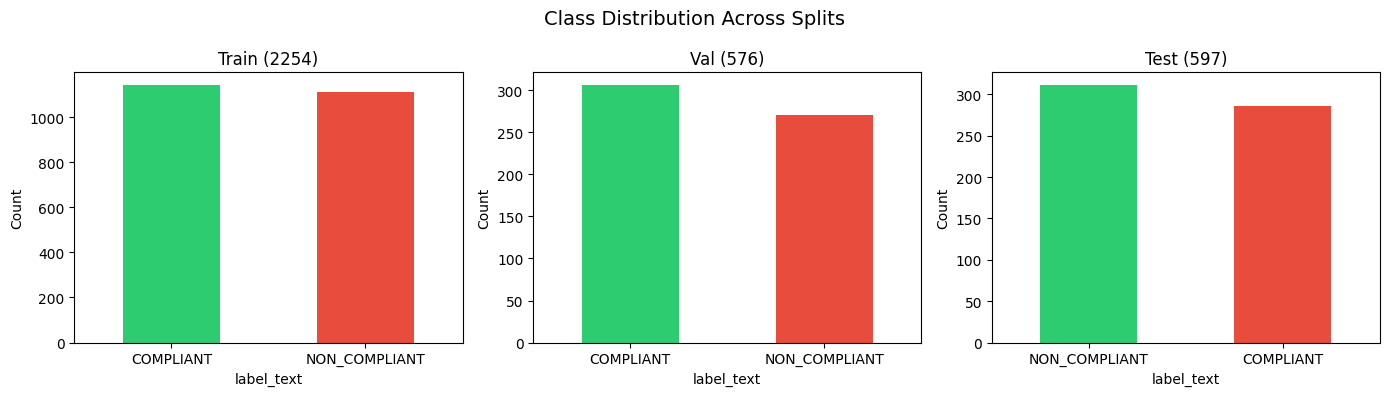

In [28]:
# Stage 2a: Class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    df['label_text'].value_counts().plot.bar(ax=ax, color=['#2ecc71','#e74c3c'])
    ax.set_title(f'{name} ({len(df)})')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Class Distribution Across Splits', fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

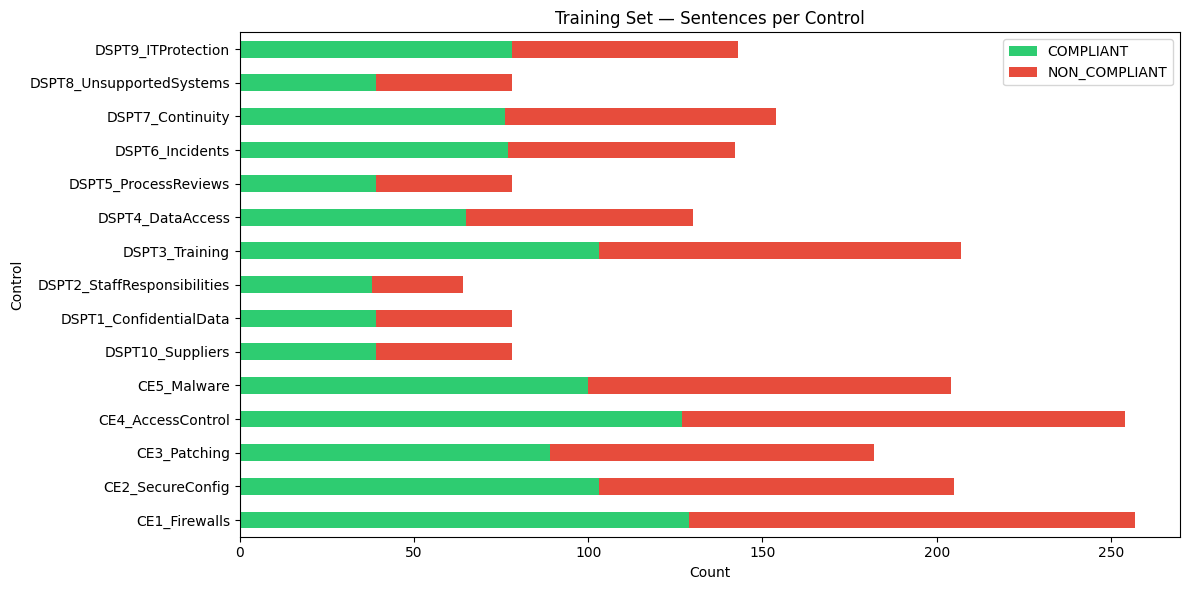

In [29]:
# Stage 2b: Control distribution in training set
plt.figure(figsize=(12, 5))
ctrl_counts = train_df.groupby(['control', 'label_text']).size().unstack(fill_value=0)
ctrl_counts.plot.barh(stacked=True, color=['#2ecc71','#e74c3c'], figsize=(12,6))
plt.title('Training Set — Sentences per Control')
plt.xlabel('Count')
plt.ylabel('Control')
plt.legend(['COMPLIANT', 'NON_COMPLIANT'])
plt.tight_layout()
plt.show()

Mean sentence length: 12.6 words
Median: 12
Range: 1 — 25


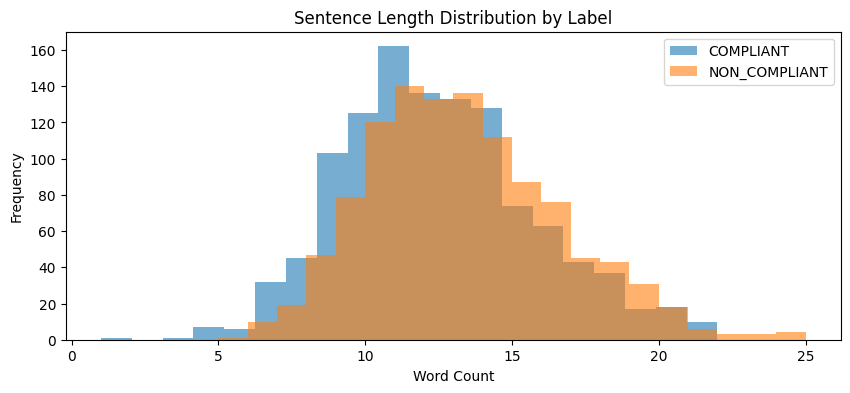

In [30]:
# Stage 2c: Sentence length distribution
train_df['word_count'] = train_df['sentence_text'].str.split().str.len()
print(f'Mean sentence length: {train_df["word_count"].mean():.1f} words')
print(f'Median: {train_df["word_count"].median():.0f}')
print(f'Range: {train_df["word_count"].min()} — {train_df["word_count"].max()}')

plt.figure(figsize=(10, 4))
train_df.groupby('label_text')['word_count'].plot.hist(
    alpha=0.6, bins=20, legend=True)
plt.title('Sentence Length Distribution by Label')
plt.xlabel('Word Count')
plt.show()

Stage 3: Feature Extraction (TF-IDF)

In [4]:
#tfidf = TfidfVectorizer(
    #ngram_range=(1, 2),       unigrams + bigrams
    #max_features=5000,        cap vocabulary
    #stop_words='english',     remove common words
    #sublinear_tf=True,        apply log normalisation
   # min_df=2,                 ignore very rare terms
#)

In [48]:
# Stage 3: TF-IDF Vectorisation
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    stop_words=None,        # <-- changed from 'english'
    sublinear_tf=True,
    min_df=2,
)


In [49]:
# Fit on training data ONLY to prevent data leakage
X_train = tfidf.fit_transform(train_df['sentence_text'])
X_val   = tfidf.transform(val_df['sentence_text'])
X_test  = tfidf.transform(test_df['sentence_text'])

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f'TF-IDF vocabulary size: {len(tfidf.vocabulary_)}')
print(f'X_train shape: {X_train.shape}')

TF-IDF vocabulary size: 4705
X_train shape: (2254, 4705)


Stage 4: Model Training and Hyperparameter Tuning

In [50]:
# Stage 4a: Logistic Regression
print('='*60)
print('LOGISTIC REGRESSION')
print('='*60)

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000],
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
lr_grid.fit(X_train, y_train)

lr_best = lr_grid.best_estimator_
lr_val_pred = lr_best.predict(X_val)

print(f'Best params : {lr_grid.best_params_}')
print(f'Best CV F1  : {lr_grid.best_score_:.4f}')
print(f'Val F1      : {f1_score(y_val, lr_val_pred, average="macro"):.4f}')
print(f'Val Accuracy: {accuracy_score(y_val, lr_val_pred):.4f}')

LOGISTIC REGRESSION
Best params : {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1  : 0.9489
Val F1      : 0.7830
Val Accuracy: 0.7830


In [51]:
# Stage 4b: Random Forest
print('='*60)
print('RANDOM FOREST')
print('='*60)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_val_pred = rf_best.predict(X_val)

print(f'Best params : {rf_grid.best_params_}')
print(f'Best CV F1  : {rf_grid.best_score_:.4f}')
print(f'Val F1      : {f1_score(y_val, rf_val_pred, average="macro"):.4f}')
print(f'Val Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}')

RANDOM FOREST
Best params : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1  : 0.9075
Val F1      : 0.8068
Val Accuracy: 0.8073


In [52]:
# Stage 4c: XGBoost
print('='*60)
print('XGBOOST')
print('='*60)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    xgb_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_val_pred = xgb_best.predict(X_val)

print(f'Best params : {xgb_grid.best_params_}')
print(f'Best CV F1  : {xgb_grid.best_score_:.4f}')
print(f'Val F1      : {f1_score(y_val, xgb_val_pred, average="macro"):.4f}')
print(f'Val Accuracy: {accuracy_score(y_val, xgb_val_pred):.4f}')

XGBOOST
Best params : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1  : 0.8809
Val F1      : 0.7862
Val Accuracy: 0.7865


Stage 5: Validation Set Comparison

In [53]:
# Stage 5: Validation set comparison table
models = {
    'Logistic Regression': (lr_best, lr_val_pred),
    'Random Forest':       (rf_best, rf_val_pred),
    'XGBoost':             (xgb_best, xgb_val_pred),
}

val_results = []
for name, (model, preds) in models.items():
    val_results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_val, preds),
        'Precision': precision_score(y_val, preds, average='macro'),
        'Recall':    recall_score(y_val, preds, average='macro'),
        'F1 (macro)': f1_score(y_val, preds, average='macro'),
    })

val_table = pd.DataFrame(val_results).set_index('Model')
print('VALIDATION SET RESULTS')
print('='*60)
print(val_table.round(4).to_string())
print()

best_name = val_table['F1 (macro)'].idxmax()
print(f'Best on validation: {best_name} (F1 = {val_table.loc[best_name, "F1 (macro)"]:.4f})')

VALIDATION SET RESULTS
                     Accuracy  Precision  Recall  F1 (macro)
Model                                                       
Logistic Regression    0.7830     0.7854  0.7857      0.7830
Random Forest          0.8073     0.8065  0.8073      0.8068
XGBoost                0.7865     0.7862  0.7873      0.7862

Best on validation: Random Forest (F1 = 0.8068)


Stage 6: Final Evaluattion on Held-Outt Test Set

In [54]:
# Stage 6a: Test set predictions
lr_test_pred  = lr_best.predict(X_test)
rf_test_pred  = rf_best.predict(X_test)
xgb_test_pred = xgb_best.predict(X_test)

test_models = {
    'Logistic Regression': lr_test_pred,
    'Random Forest':       rf_test_pred,
    'XGBoost':             xgb_test_pred,
}

test_results = []
for name, preds in test_models.items():
    test_results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='macro'),
        'Recall':    recall_score(y_test, preds, average='macro'),
        'F1 (macro)': f1_score(y_test, preds, average='macro'),
    })

test_table = pd.DataFrame(test_results).set_index('Model')
print('TEST SET RESULTS')
print('='*60)
print(test_table.round(4).to_string())
print()

best_test = test_table['F1 (macro)'].idxmax()
print(f'Best on test: {best_test} (F1 = {test_table.loc[best_test, "F1 (macro)"]:.4f})')

TEST SET RESULTS
                     Accuracy  Precision  Recall  F1 (macro)
Model                                                       
Logistic Regression    0.8392     0.8391  0.8386      0.8388
Random Forest          0.8727     0.8724  0.8726      0.8725
XGBoost                0.8526     0.8524  0.8529      0.8525

Best on test: Random Forest (F1 = 0.8725)


In [55]:
# Stage 6b: Classification reports for all three models
target_names = ['NON_COMPLIANT', 'COMPLIANT']

for name, preds in test_models.items():
    print('='*60)
    print(f'{name} — Classification Report')
    print('='*60)
    print(classification_report(y_test, preds, target_names=target_names))
    print()

Logistic Regression — Classification Report
               precision    recall  f1-score   support

NON_COMPLIANT       0.84      0.85      0.85       311
    COMPLIANT       0.84      0.83      0.83       286

     accuracy                           0.84       597
    macro avg       0.84      0.84      0.84       597
 weighted avg       0.84      0.84      0.84       597


Random Forest — Classification Report
               precision    recall  f1-score   support

NON_COMPLIANT       0.88      0.87      0.88       311
    COMPLIANT       0.86      0.87      0.87       286

     accuracy                           0.87       597
    macro avg       0.87      0.87      0.87       597
 weighted avg       0.87      0.87      0.87       597


XGBoost — Classification Report
               precision    recall  f1-score   support

NON_COMPLIANT       0.87      0.85      0.86       311
    COMPLIANT       0.84      0.86      0.85       286

     accuracy                           0.85       

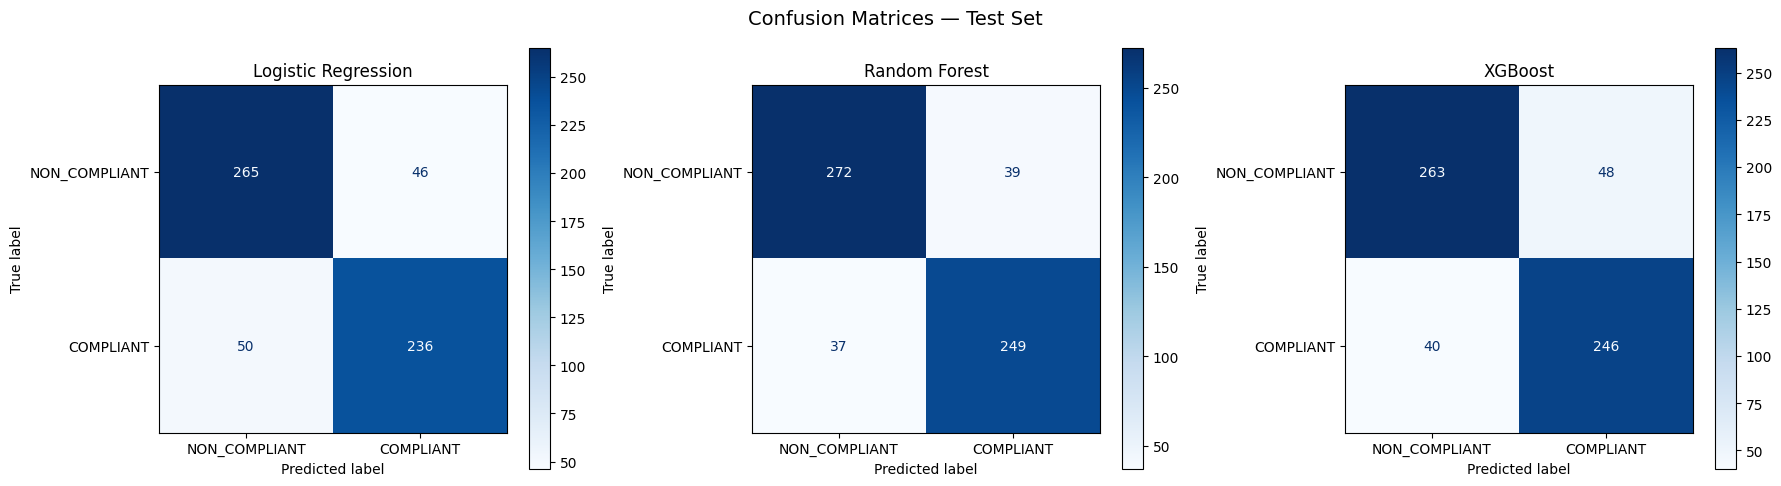

In [56]:
# Stage 6c: Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, test_models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

Stage 7: Per-Control Breakout

PER-CONTROL BREAKDOWN — Random Forest
                              N      F1  Accuracy
Control                                          
CE1_Firewalls                65  0.9675    0.9692
CE2_SecureConfig             65  0.7756    0.7846
CE3_Patching                 39  0.9443    0.9487
CE4_AccessControl            52  0.9615    0.9615
CE5_Malware                  38  0.5522    0.6316
DSPT10_Suppliers             26  0.8844    0.8846
DSPT1_ConfidentialData       26  0.8844    0.8846
DSPT2_StaffResponsibilities  26  0.9226    0.9231
DSPT3_Training               52  0.8441    0.8462
DSPT4_DataAccess             39  0.7056    0.7179
DSPT5_ProcessReviews         26  1.0000    1.0000
DSPT6_Incidents              26  0.9615    0.9615
DSPT7_Continuity             39  0.7068    0.7692
DSPT8_UnsupportedSystems     39  0.9177    0.9231
DSPT9_ITProtection           39  0.9423    0.9487


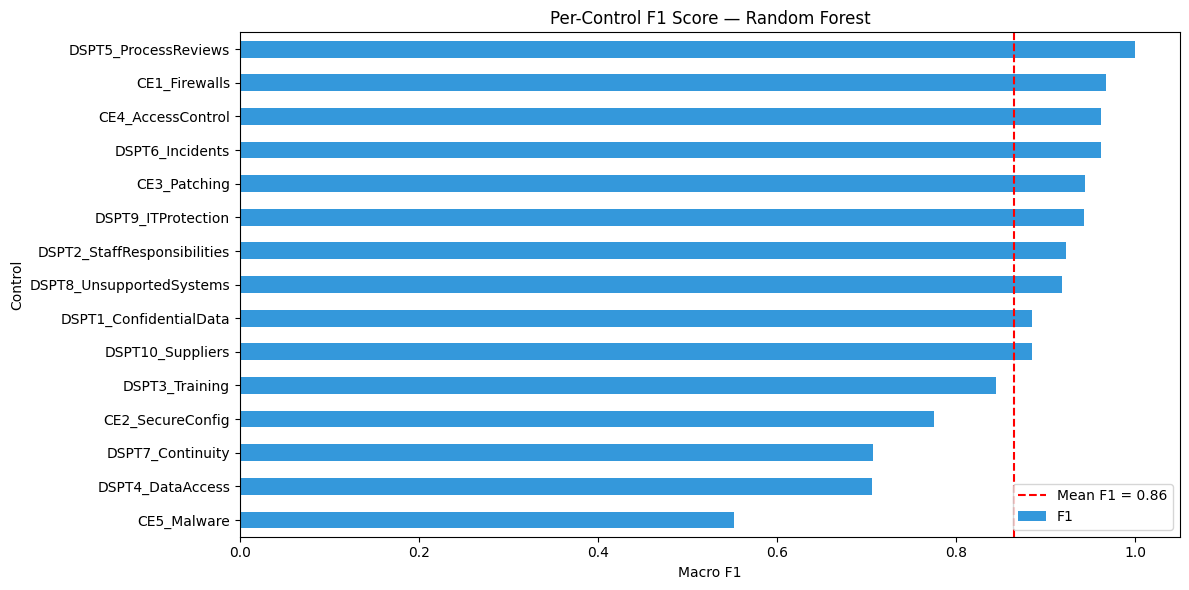

In [57]:
# Stage 7: Per-control F1 for the best model
best_preds = test_models[best_test]

controls = sorted(test_df['control'].unique())
per_control = []

for ctrl in controls:
    mask = test_df['control'] == ctrl
    y_c  = y_test[mask]
    p_c  = best_preds[mask]

    if len(set(y_c)) < 2:
        f1 = np.nan
    else:
        f1 = f1_score(y_c, p_c, average='macro')

    per_control.append({
        'Control': ctrl,
        'N': len(y_c),
        'F1': f1,
        'Accuracy': accuracy_score(y_c, p_c),
    })

pc_df = pd.DataFrame(per_control).set_index('Control')
print(f'PER-CONTROL BREAKDOWN — {best_test}')
print('='*60)
print(pc_df.round(4).to_string())

# Visualise
plt.figure(figsize=(12, 6))
pc_df['F1'].sort_values().plot.barh(color='#3498db')
plt.axvline(x=pc_df['F1'].mean(), color='red', linestyle='--', label=f'Mean F1 = {pc_df["F1"].mean():.2f}')
plt.title(f'Per-Control F1 Score — {best_test}')
plt.xlabel('Macro F1')
plt.legend()
plt.tight_layout()
plt.show()

Stage 8: False Positive Analysis (Deployment Risk)

In [58]:
# Stage 8: False positive analysis
test_df_copy = test_df.copy()
test_df_copy['predicted'] = best_preds
test_df_copy['pred_text'] = test_df_copy['predicted'].map({1: 'COMPLIANT', 0: 'NON_COMPLIANT'})

# False positives: actually non-compliant (0) but predicted compliant (1)
fp = test_df_copy[(test_df_copy['label'] == 0) & (test_df_copy['predicted'] == 1)]

# False negatives: actually compliant (1) but predicted non-compliant (0)
fn = test_df_copy[(test_df_copy['label'] == 1) & (test_df_copy['predicted'] == 0)]

total_nc = (test_df_copy['label'] == 0).sum()
total_c  = (test_df_copy['label'] == 1).sum()

print('DEPLOYMENT RISK ANALYSIS')
print('='*60)
print(f'False positives (dangerous — missed non-compliance): {len(fp)}/{total_nc} ({len(fp)/total_nc*100:.1f}%)')
print(f'False negatives (unnecessary review):                {len(fn)}/{total_c} ({len(fn)/total_c*100:.1f}%)')
print()

if len(fp) > 0:
    print('FALSE POSITIVE SENTENCES (non-compliant predicted as compliant):')
    print('-'*60)
    print(f'False positives (dangerous — missed non-compliance): {len(fp)}/{total_nc} ({len(fp)/total_nc*100:.1f}%)')
print(f'False negatives (unnecessary review):                {len(fn)}/{total_c} ({len(fn)/total_c*100:.1f}%)')
print()

if len(fp) > 0:
    print('FALSE POSITIVE SENTENCES (non-compliant predicted as compliant):')
    print('-'*60)
    for r in fp.itertuples():
        print(f'  [{r.control}] {r.sentence_text}')
    print()
    print('Per-control false positive distribution:')
    print(fp['control'].value_counts().to_string())
else:
    print('No false positives — all non-compliant statements correctly identified.')

DEPLOYMENT RISK ANALYSIS
False positives (dangerous — missed non-compliance): 39/311 (12.5%)
False negatives (unnecessary review):                37/286 (12.9%)

FALSE POSITIVE SENTENCES (non-compliant predicted as compliant):
------------------------------------------------------------
False positives (dangerous — missed non-compliance): 39/311 (12.5%)
False negatives (unnecessary review):                37/286 (12.9%)

FALSE POSITIVE SENTENCES (non-compliant predicted as compliant):
------------------------------------------------------------
  [CE2_SecureConfig] USB devices run automatically as soon as they are plugged in.
  [CE5_Malware] No controls exist to stop unapproved programs running on our computers.
  [DSPT4_DataAccess] Access rights are never removed, even when staff move to different roles.
  [DSPT7_Continuity] The only copy of our data is on the machine in the office.
  [CE2_SecureConfig] USB devices are automatically inserted into the system as soon as they are plugged

Stage 9: Feature Importance (Explainibility)

TOP 20 FEATURES — COMPLIANT
  our                            +9.0004
  all                            +8.5033
  and                            +7.0694
  automatically                  +6.2342
  not permitted                  +5.8654
  firewall admin                 +5.8371
  is in                          +5.4471
  required for                   +5.2821
  our computers                  +5.2421
  are                            +4.8530
  year                           +4.7728
  business                       +4.7601
  applications                   +4.7595
  confidentiality obligations    +4.7047
  business continuity            +4.6905
  incoming traffic               +4.6756
  are complete                   +4.6699
  cyber essentials               +4.6429
  essentials                     +4.6429
  monthly                        +4.6312

TOP 20 FEATURES — NON-COMPLIANT
  not                            -19.6722
  no                             -15.5573
  must                           -1

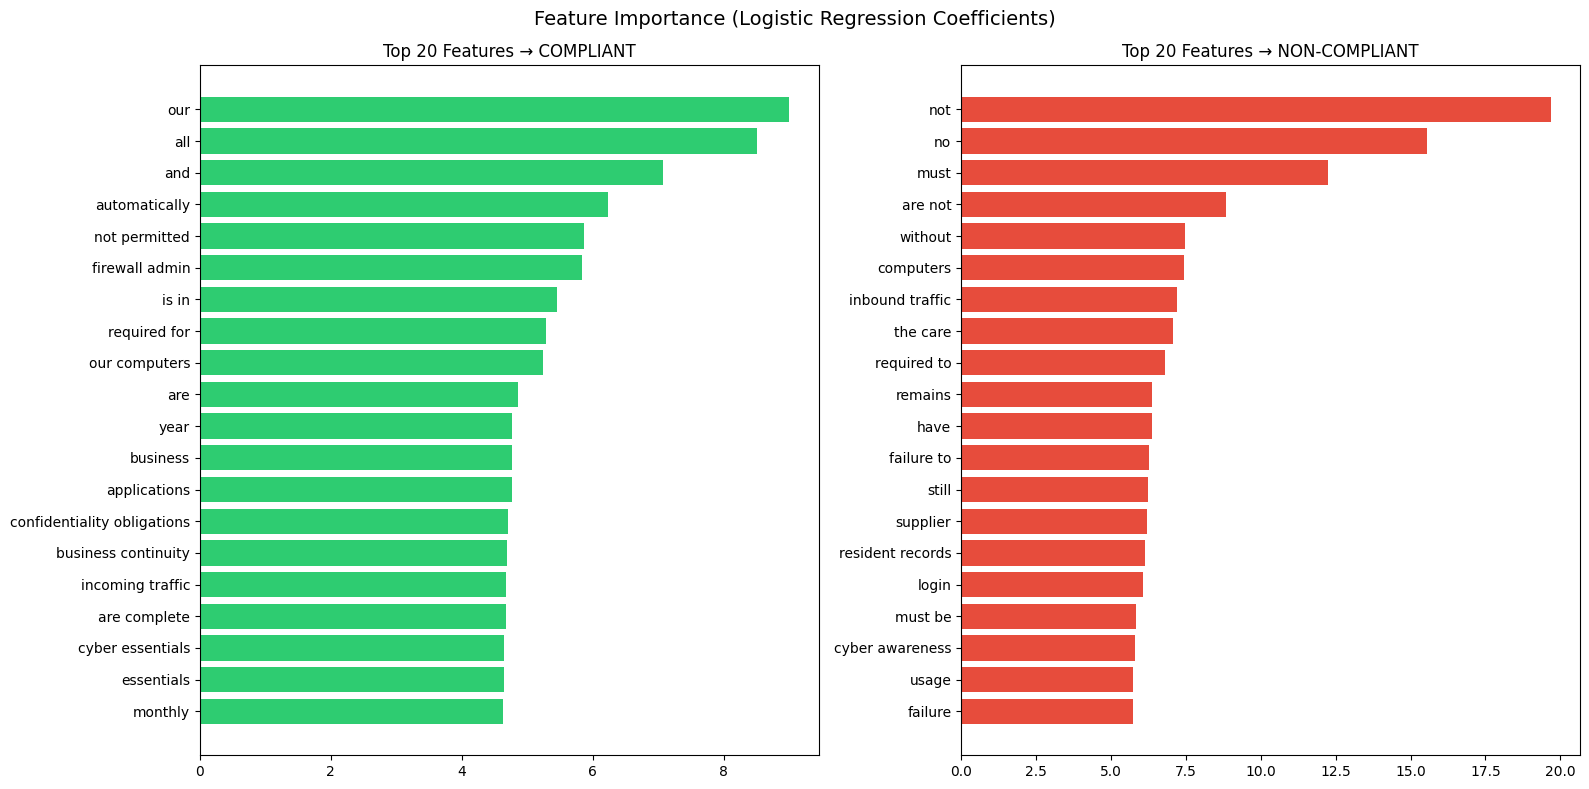

In [59]:
# Stage 9: Top features for compliance vs non-compliance
feature_names = tfidf.get_feature_names_out()

# Use Logistic Regression coefficients (most interpretable)
coefs = lr_best.coef_[0]
top_n = 20

# Most indicative of COMPLIANT (label=1)
top_compliant = np.argsort(coefs)[-top_n:][::-1]
# Most indicative of NON_COMPLIANT (label=0)
top_non_compliant = np.argsort(coefs)[:top_n]

print('TOP 20 FEATURES — COMPLIANT')
print('='*40)
for i in top_compliant:
    print(f'  {feature_names[i]:30s} {coefs[i]:+.4f}')

print()
print('TOP 20 FEATURES — NON-COMPLIANT')
print('='*40)
for i in top_non_compliant:
    print(f'  {feature_names[i]:30s} {coefs[i]:+.4f}')

# Visualise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.barh([feature_names[i] for i in top_compliant[::-1]],
         [coefs[i] for i in top_compliant[::-1]], color='#2ecc71')
ax1.set_title('Top 20 Features → COMPLIANT')

ax2.barh([feature_names[i] for i in top_non_compliant[::-1]],
         [abs(coefs[i]) for i in top_non_compliant[::-1]], color='#e74c3c')
ax2.set_title('Top 20 Features → NON-COMPLIANT')

plt.suptitle('Feature Importance (Logistic Regression Coefficients)', fontsize=14)
plt.tight_layout()
plt.show()

Stage 10: Save Model and Resuls

In [60]:
# Stage 10: Save artefacts
import joblib

# Save all three trained models
joblib.dump(lr_best, 'model_logistic_regression.joblib')
joblib.dump(rf_best, 'model_random_forest.joblib')
joblib.dump(xgb_best, 'model_xgboost.joblib')

# Save the TF-IDF vectoriser (needed at inference time)
joblib.dump(tfidf, 'tfidf_vectoriser.joblib')

# Save results tables
val_table.round(4).to_csv('validation_results.csv')
test_table.round(4).to_csv('test_results.csv')
pc_df.round(4).to_csv('per_control_results.csv')

# Save test predictions for later comparison with LLM
test_df_copy.to_csv('test_predictions_supervised.csv', index=False)

print('Saved:')
print('  model_logistic_regression.joblib')
print('  model_random_forest.joblib')
print('  model_xgboost.joblib')
print('  tfidf_vectoriser.joblib')
print('  validation_results.csv')
print('  test_results.csv')
print('  per_control_results.csv')
print('  test_predictions_supervised.csv')
print()
print('Download these files for the web prototype and LLM comparison.')

Saved:
  model_logistic_regression.joblib
  model_random_forest.joblib
  model_xgboost.joblib
  tfidf_vectoriser.joblib
  validation_results.csv
  test_results.csv
  per_control_results.csv
  test_predictions_supervised.csv

Download these files for the web prototype and LLM comparison.


In [61]:
# Stage 10b: Download files from Colab
from google.colab import files

for f in ['model_logistic_regression.joblib', 'model_random_forest.joblib',
          'model_xgboost.joblib', 'tfidf_vectoriser.joblib',
          'validation_results.csv', 'test_results.csv',
          'per_control_results.csv', 'test_predictions_supervised.csv']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>